# Feature Engineering

Notebook 5 set the statistical baseline: SARIMAX models the time dependence **inside** the
algorithm. The next step of the benchmark is a Machine Learning model. A standard
regressor has no notion of time or order: it sees a table of rows `X → y`, so the temporal
structure has to be written into the columns of `X`.

This notebook builds that table for the **same series as notebook 5**: monthly international
arrivals to Brazil, aggregated over all access routes, origins and destination states. It
covers feature engineering only; model training comes next.

Each step follows the same layout:

1. **What** is built and **why** it is relevant for this series.
2. **How**: the book helper used and the parameters chosen.
3. **Output**: the new columns, a sample of their values and a plot or check.

## Setup

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

TARGET = 'arrival_count'
TS_ID = 'series_id'
FREQ = 'ME'
SEASONAL_PERIOD = 12

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)

### Book Helpers

The feature functions come from the companion repository of:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2nd ed.
> (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), MIT License

| Helper | Module | Used in step |
|---|---|---|
| `add_lags` | `src/feature_engineering/autoregressive_features.py` | Lags, COVID flags at lag positions |
| `add_rolling_features` | `src/feature_engineering/autoregressive_features.py` | Rolling window aggregations |
| `add_seasonal_rolling_features` | `src/feature_engineering/autoregressive_features.py` | Seasonal rolling aggregations |
| `add_ewma` | `src/feature_engineering/autoregressive_features.py` | EWMA |
| `add_temporal_features` | `src/feature_engineering/temporal_features.py` | Calendar features and elapsed time |
| `add_fourier_features` | `src/feature_engineering/temporal_features.py` | Fourier terms |

Notes on using them here:

- **`ts_id` is always passed**, even though there is a single series (a constant
  `series_id` column). Without `ts_id`, `add_seasonal_rolling_features` calls
  `Series.transform(lambda ...)`, which pandas 2.x applies element by element
  (`ValueError: Function did not transform`). The grouped path passes the whole series.
- **`add_ewma` is called with `spans`.** With only `alphas`, the helper reads an undefined
  variable (`use_spans`) and fails.
- **`add_fourier_features` is called with `max_value=12`.** Without it, the helper raises
  instead of warning.
- `add_seasonal_rolling_features` needs the `window-ops` package (a project dependency).

The repository is expected as a sibling folder of this project (override with the
`MTSF_REPO_PATH` environment variable).

In [2]:
# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.feature_engineering.autoregressive_features import (  # noqa: E402
    add_ewma,
    add_lags,
    add_rolling_features,
    add_seasonal_rolling_features,
)
from src.feature_engineering.temporal_features import (  # noqa: E402
    add_fourier_features,
    add_temporal_features,
)

## Step 1 — Casting the Series as a Supervised Regression

**What.** The series `{y₁, …, y_T}` becomes a table: each row is a month `t`, the target
column is `y_t`, and the feature columns summarize what was known **before** `t`.

**How.**

- Monthly totals are built from `train.parquet` and `val.parquet`, the same aggregation as
  notebook 5. The validation set is the 12 months before the test year (notebook 2), and the
  dates used below (`TRAIN_END`, `VAL_START`, `HORIZON`) are read from these files, so the
  notebook follows the data when it is updated. The **test set is never read here**: it is
  kept for the final evaluation only.
- Train and validation are **joined** before building features, and a `split` column keeps
  them apart. Features for the first validation month need the values of the last training
  months, which only exist in the training file. If the validation set were processed alone,
  its first rows would have no lags.
- The joined table is safe only if no feature of row `t` reads `y_t` or a later value. Every
  target-derived feature is shifted for that reason, and Step 11 tests it.

In [3]:
def load_monthly(file_name, split):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    monthly = raw.set_index('date')[[TARGET]].resample(FREQ).sum()
    monthly['split'] = split
    return monthly


monthly = pd.concat([
    load_monthly('train.parquet', 'train'),
    load_monthly('val.parquet', 'val'),
]).reset_index()
monthly[TS_ID] = 'brazil_total'
monthly = monthly[['date', TS_ID, 'split', TARGET]]

# every date of this notebook is derived from the split (notebook 2)
TRAIN_END = monthly.loc[monthly['split'] == 'train', 'date'].max()
VAL_START = monthly.loc[monthly['split'] == 'val', 'date'].min()
HORIZON = int((monthly['split'] == 'val').sum())
assert VAL_START == TRAIN_END + pd.offsets.MonthEnd(1), 'validation must follow train'

for split, part in monthly.groupby('split', sort=False):
    print(
        f'{split:<5}: {part["date"].min():%b %Y} → {part["date"].max():%b %Y} '
        f'({len(part)} months)'
    )
print(f'HORIZON = {HORIZON} months')
display(monthly.tail(15))

train: Jan 1989 → Aug 2024 (428 months)
val  : Sep 2024 → Aug 2025 (12 months)
HORIZON = 12 months


,date,series_id,split,arrival_count
425,2024-06-30,brazil_total,train,332474.0
426,2024-07-31,brazil_total,train,437103.0
427,2024-08-31,brazil_total,train,417940.0
428,2024-09-30,brazil_total,val,445389.0
429,2024-10-31,brazil_total,val,508738.0
430,2024-11-30,brazil_total,val,560732.0
431,2024-12-31,brazil_total,val,806478.0
432,2025-01-31,brazil_total,val,1483669.0
433,2025-02-28,brazil_total,val,1326884.0
434,2025-03-31,brazil_total,val,929096.0


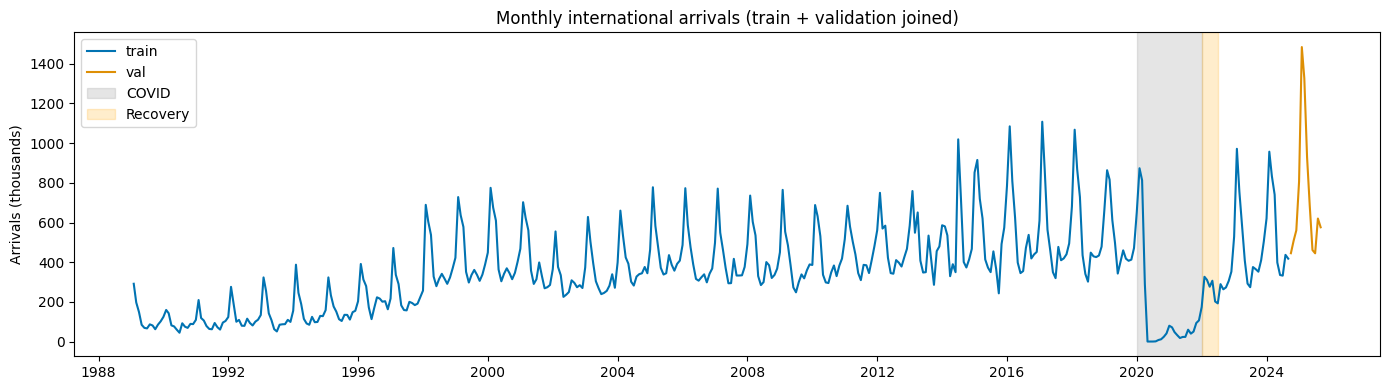

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
for split, part in monthly.groupby('split', sort=False):
    ax.plot(part['date'], part[TARGET] / 1e3, label=split)
ax.axvspan(COVID_START, COVID_END, color='grey', alpha=0.2, label='COVID')
ax.axvspan(
    POST_COVID_START, COVID_RECOVERY_END, color='orange', alpha=0.2, label='Recovery'
)
ax.set_title('Monthly international arrivals (train + validation joined)')
ax.set_ylabel('Arrivals (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

**Sliding window illustration.** With a memory of `M = 3` months, the rows of the table look
like the frame below: the three previous values are the inputs and the current value is the
target. The following steps generalize this idea to lags, windows and summaries chosen for
this series.

In [5]:
M = 3
window_example = pd.DataFrame(
    {f'y(t-{k})': monthly[TARGET].shift(k) for k in range(M, 0, -1)}
    | {'y(t) → target': monthly[TARGET]}
).set_index(monthly['date'].dt.strftime('%b %Y'))
window_example.iloc[M : M + 6]

,y(t-3),y(t-2),y(t-1),y(t) → target
date,,,,
Apr 1989,291566.0,197348.0,149001.0,84867.0
May 1989,197348.0,149001.0,84867.0,69293.0
Jun 1989,149001.0,84867.0,69293.0,66838.0
Jul 1989,84867.0,69293.0,66838.0,87054.0
Aug 1989,69293.0,66838.0,87054.0,81535.0
Sep 1989,66838.0,87054.0,81535.0,62629.0


## Step 2 — Choosing the Memory: ACF and PACF

**What.** The lags to include depend on how far back the series "remembers".

- **ACF:** the correlation between `y_t` and `y_{t-k}`.
- **PACF:** the same correlation after removing the effect of the intermediate lags. It
  points to the lags that add **new** information.

**How.** Both are computed on the **pre-COVID training period** (1989–2019). The 2020–2021
collapse would otherwise dominate the correlations. The significant lags are those outside
the 95% confidence band.

Significant PACF lags: {1: 0.82, 2: -0.18, 4: 0.15, 5: 0.21, 7: -0.17, 8: 0.17, 9: 0.36, 10: 0.38, 11: 0.38, 12: 0.43, 13: -0.33, 14: -0.12, 24: 0.18, 25: -0.17, 32: -0.11, 34: 0.13}
ACF at 12 / 24 / 36  : [0.86, 0.75, 0.64]


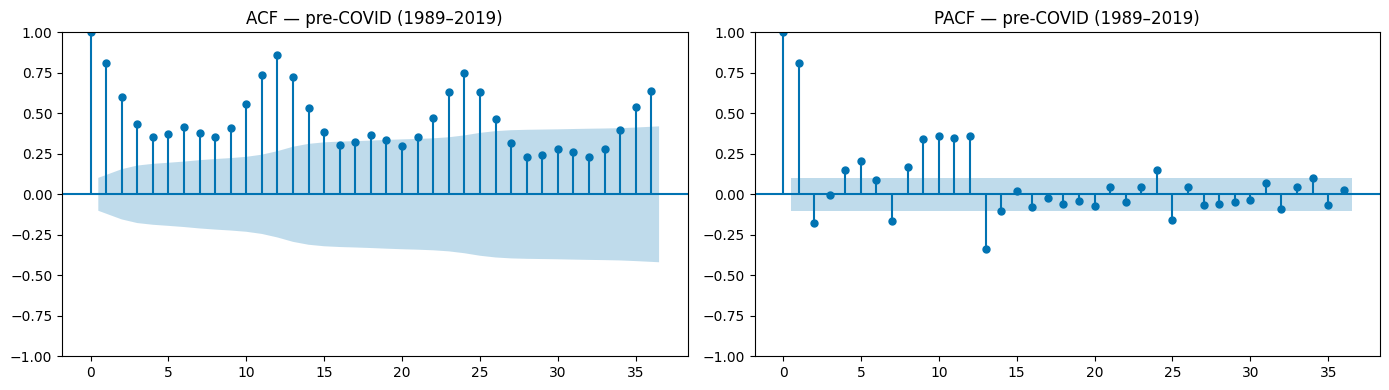

In [6]:
pre_covid = monthly.loc[
    (monthly['split'] == 'train') & (monthly['date'] < COVID_START), TARGET
]
N_LAGS = 36


def significant_lags(values, conf_int):
    half_width = conf_int[:, 1] - values
    return {
        lag: round(float(values[lag]), 2)
        for lag in range(1, len(values))
        if abs(values[lag]) > half_width[lag]
    }


acf_values, acf_ci = acf(pre_covid, nlags=N_LAGS, alpha=0.05)
pacf_values, pacf_ci = pacf(pre_covid, nlags=N_LAGS, alpha=0.05)
print('Significant PACF lags:', significant_lags(pacf_values, pacf_ci))
print('ACF at 12 / 24 / 36  :', [round(float(acf_values[k]), 2) for k in (12, 24, 36)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(pre_covid, lags=N_LAGS, ax=axes[0], title='ACF — pre-COVID (1989–2019)')
plot_pacf(pre_covid, lags=N_LAGS, ax=axes[1], title='PACF — pre-COVID (1989–2019)')
plt.tight_layout()
plt.show()

**Reading.**

- **ACF.** The ACF peaks at 12, 24 and 36, the yearly seasonality found in notebook 3. Its
  slow decay reflects the trend.
- **PACF lag 1** (≈ 0.82) carries the short-term momentum.
- **PACF lags 12 and 13** (the second one negative) are the typical *seasonal + seasonal-lag*
  pair of monthly data. Lag 24 still adds information.
- **PACF lags 9–11** are also significant. They sit on the approach to the seasonal peak and are
  mostly summarized by the rolling and seasonal features built later.

## Step 3 — Forecasting Strategies and the Leakage Rule

**What.** The forecast horizon is `HORIZON` = 12 months (the validation year). When
forecasting the last validation month from the last training month, the values of the 11
months in between are **not known**.
That fixes which lags are legal:

| Strategy | Minimum shift | How the next notebook forecasts |
|---|---|---|
| **recursive** | 1 month | One model predicts `t+1`; the prediction is fed back as `lag_1` for `t+2`, and so on for 12 steps. The target-derived features of the validation rows must be rebuilt from predictions. |
| **direct** | 12 months (`= HORIZON`) | Every feature is already known for the whole horizon, so the 12 validation months are predicted in one pass, without feeding predictions back. |

**How.** One configuration per strategy. Every target-derived feature is shifted by at least
`min_shift`.

- **Lags** are chosen from the PACF of Step 2: 1, 2, 12, 13, 24 and 36 for recursive, and
  only those ≥ 12 for direct.
- **Rolling windows** are shifted by `min_shift` before the window is applied.
- The other parameters are shared by both strategies.

The two feature tables are built side by side in each of the following steps.

In [7]:
BASE_LAGS = [1, 2, 12, 13, 24, 36]

STRATEGIES = {
    'recursive': {'min_shift': 1},
    'direct': {'min_shift': HORIZON},
}
for cfg in STRATEGIES.values():
    cfg['lags'] = [lag for lag in BASE_LAGS if lag >= cfg['min_shift']]

ROLLING_WINDOWS = [3, 6, 12]
ROLLING_AGGS = ['mean', 'std', 'min', 'max']
SEASONAL_WINDOWS = [2, 3]  # the same month of the 2 / 3 previous years
SEASONAL_AGGS = ['mean', 'std']
EWMA_SPANS = [3, 6, 12]
FOURIER_TERMS = 3

display(pd.DataFrame(STRATEGIES).T)

# one working table per strategy, filled step by step
features = {name: monthly.copy() for name in STRATEGIES}
feature_groups = {name: {} for name in STRATEGIES}

# around the train/validation boundary: the last 3 train and first 3 validation months
BOUNDARY = slice(TRAIN_END - pd.offsets.MonthEnd(2), VAL_START + pd.offsets.MonthEnd(2))


def show_step(group, columns=None, rows=BOUNDARY):
    """Summarize a step's new features and show them around the train/val boundary."""
    display(
        pd.DataFrame({
            name: {
                'n_features': len(groups[group]),
                'features': ', '.join(groups[group]),
            }
            for name, groups in feature_groups.items()
        }).T
    )
    for name, frame in features.items():
        cols = columns or feature_groups[name][group]
        cols = [c for c in cols if c in frame.columns]
        print(f'{name} — sample around the train/validation boundary')
        display(frame.set_index('date').loc[rows, ['split', TARGET, *cols]])

,min_shift,lags
recursive,1,"[1, 2, 12, 13, 24, 36]"
direct,12,"[12, 13, 24, 36]"


## Step 4 — Lags (Time Delay Embedding)

**What.** A lag `y_{t-k}` places the value observed `k` months earlier on the row of month
`t`. It encodes the autoregressive structure:

- `lag_1`: momentum, i.e. where the series was last month.
- `lag_12`: the same month last year, which carries the seasonal level.
- `lag_13`, `lag_24`, `lag_36`: the seasonal pattern of previous years.

**How.** `add_lags(df, lags, column, ts_id)` (book) shifts the series by each lag.

**Output.** Near the train/validation boundary, the recursive `lag_1` of the second
validation month holds the **actual** value of the first validation month. That value is
legitimate only in one-step-ahead mode, which is why Step 13 masks it for the recursive
validation rows. For the direct strategy, every lag of a validation row points to the
training period.

In [8]:
def add_lag_features(df, cfg):
    return add_lags(df, lags=cfg['lags'], column=TARGET, ts_id=TS_ID)


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['lags'] = add_lag_features(features[name], cfg)

show_step('lags')

,n_features,features
recursive,6,"arrival_count_lag_1, arrival_count_lag_2, arri..."
direct,4,"arrival_count_lag_12, arrival_count_lag_13, ar..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_lag_1,arrival_count_lag_2,arrival_count_lag_12,arrival_count_lag_13,arrival_count_lag_24,arrival_count_lag_36
date,,,,,,,,
2024-06-30,train,332474.0,335652.0,398587.0,274302.0,292375.0,192909.0,24070.0
2024-07-31,train,437103.0,332474.0,335652.0,375648.0,274302.0,289581.0,60270.0
2024-08-31,train,417940.0,437103.0,332474.0,365041.0,375648.0,263626.0,40410.0
2024-09-30,val,445389.0,417940.0,437103.0,352355.0,365041.0,273004.0,50675.0
2024-10-31,val,508738.0,445389.0,417940.0,409924.0,352355.0,305644.0,93824.0
2024-11-30,val,560732.0,508738.0,445389.0,504395.0,409924.0,352458.0,107123.0


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_lag_12,arrival_count_lag_13,arrival_count_lag_24,arrival_count_lag_36
date,,,,,,
2024-06-30,train,332474.0,274302.0,292375.0,192909.0,24070.0
2024-07-31,train,437103.0,375648.0,274302.0,289581.0,60270.0
2024-08-31,train,417940.0,365041.0,375648.0,263626.0,40410.0
2024-09-30,val,445389.0,352355.0,365041.0,273004.0,50675.0
2024-10-31,val,508738.0,409924.0,352355.0,305644.0,93824.0
2024-11-30,val,560732.0,504395.0,409924.0,352458.0,107123.0


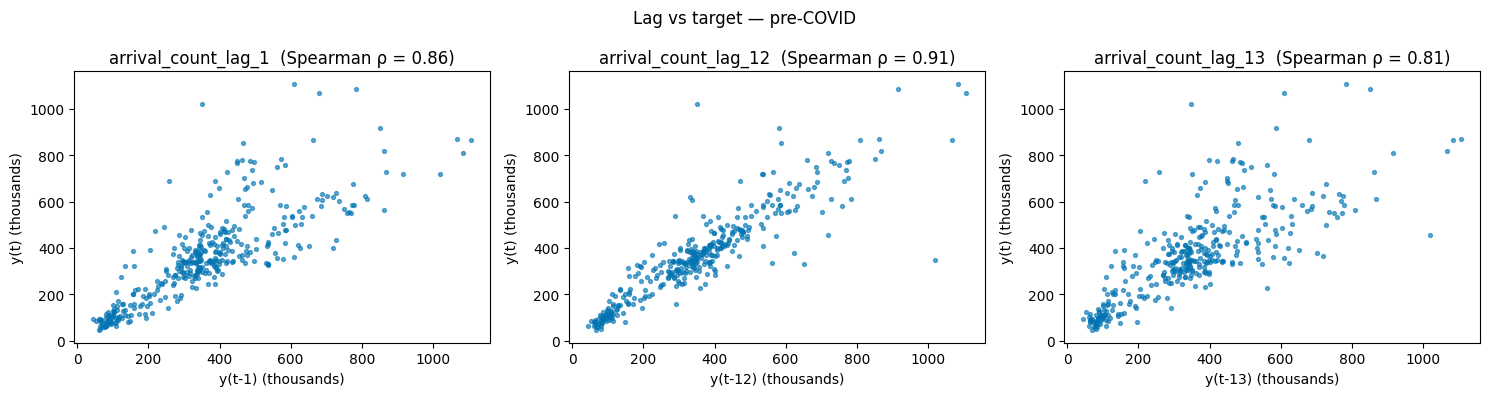

In [9]:
lag_view = features['recursive'].query('date < @COVID_START')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lag in zip(axes, [1, 12, 13]):
    col = f'{TARGET}_lag_{lag}'
    rho = lag_view[[col, TARGET]].corr(method='spearman').iloc[0, 1]
    ax.scatter(lag_view[col] / 1e3, lag_view[TARGET] / 1e3, s=8, alpha=0.6)
    ax.set_title(f'{col}  (Spearman ρ = {rho:.2f})')
    ax.set_xlabel(f'y(t-{lag}) (thousands)')
    ax.set_ylabel('y(t) (thousands)')
fig.suptitle('Lag vs target — pre-COVID')
plt.tight_layout()
plt.show()

## Step 5 — Rolling Window Aggregations

**What.** A single lag is noisy. A rolling window summarizes the last `W` observations
`{y_{t-W}, …, y_{t-1}}`:

- **mean:** the local level. The 12-month mean removes the seasonality, so it tracks the trend.
- **std:** the local volatility. It is high around the COVID collapse and in high seasons.
- **min / max:** the range of the window.

**How.** `add_rolling_features(df, rolls, column, agg_funcs, ts_id, n_shift)` (book). The
series is first shifted by `n_shift = min_shift` and then rolled. For the direct strategy, the
12-month mean of the last validation month therefore covers the last 12 training months.

**Output.** The plot shows the same 12-month mean for both strategies. The direct version is
the recursive one moved 12 months later, which is the cost of knowing it for the whole horizon.

In [10]:
def add_rolling_window_features(df, cfg):
    return add_rolling_features(
        df,
        rolls=ROLLING_WINDOWS,
        column=TARGET,
        agg_funcs=ROLLING_AGGS,
        ts_id=TS_ID,
        n_shift=cfg['min_shift'],
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['rolling'] = add_rolling_window_features(
        features[name], cfg
    )

show_step(
    'rolling',
    columns=[
        f'{TARGET}_rolling_3_mean',
        f'{TARGET}_rolling_12_mean',
        f'{TARGET}_rolling_12_std',
    ],
)

,n_features,features
recursive,12,"arrival_count_rolling_3_mean, arrival_count_ro..."
direct,12,"arrival_count_rolling_3_mean, arrival_count_ro..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_rolling_3_mean,arrival_count_rolling_12_mean,arrival_count_rolling_12_std
date,,,,,
2024-06-30,train,332474.0,491574.000000,513966.750000,221917.074675
2024-07-31,train,437103.0,355571.000000,518814.416667,216781.728474
2024-08-31,train,417940.0,368409.666667,523935.666667,213797.461958
2024-09-30,val,445389.0,395839.000000,528343.916667,210746.999628
2024-10-31,val,508738.0,433477.333333,536096.750000,205325.776332
2024-11-30,val,560732.0,457355.666667,544331.250000,201756.079815


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_rolling_3_mean,arrival_count_rolling_12_mean,arrival_count_rolling_12_std
date,,,,,
2024-06-30,train,332474.0,325158.333333,441096.500000,226897.971684
2024-07-31,train,437103.0,314108.333333,448268.750000,222999.969521
2024-08-31,train,417940.0,338330.333333,456720.000000,217212.857520
2024-09-30,val,445389.0,364348.000000,463332.583333,212263.012164
2024-10-31,val,508738.0,375773.333333,472022.583333,207296.898175
2024-11-30,val,560732.0,422224.666667,484684.000000,203943.082530


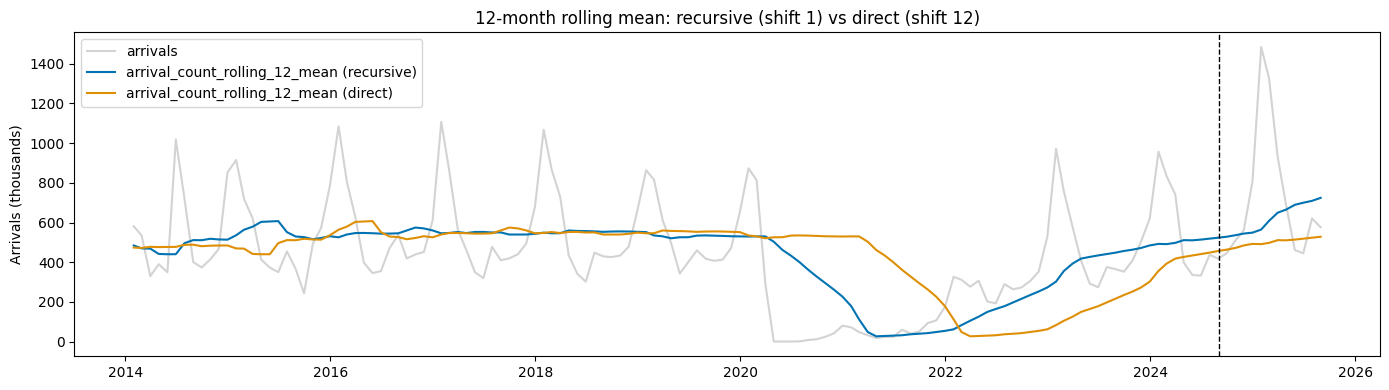

In [11]:
col = f'{TARGET}_rolling_12_mean'
fig, ax = plt.subplots(figsize=(14, 4))
view = monthly.query('date >= "2014-01-01"')
ax.plot(view['date'], view[TARGET] / 1e3, color='lightgrey', label='arrivals')
for name, frame in features.items():
    frame_view = frame.query('date >= "2014-01-01"')
    ax.plot(frame_view['date'], frame_view[col] / 1e3, label=f'{col} ({name})')
ax.axvline(TRAIN_END + pd.Timedelta(days=1), color='black', linestyle='--', linewidth=1)
ax.set_title('12-month rolling mean: recursive (shift 1) vs direct (shift 12)')
ax.set_ylabel('Arrivals (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6 — Seasonal Rolling Aggregations

**What.** A seasonal rolling window skips `M = 12` months between its elements. For month `t`
it summarizes `{y_{t-12}, y_{t-24}, …}`: the **same calendar month** of previous years.

- **mean:** a "typical January" computed from the last 2 or 3 Januaries. This is the
  strongest single signal for a strongly seasonal monthly series.
- **std:** how stable that month has been across years.

**How.** `add_seasonal_rolling_features(df, seasonal_periods=[12], rolls, column, agg_funcs,
ts_id, n_shift=1)` (book, backed by `window_ops`). Here `n_shift` counts **seasons**: the series
is shifted by `1 × 12` months before the window, so the most recent element is `y_{t-12}`. This
is legal for both strategies, so both use the same parameters.

**Output.** A manual check confirms the definition. The plot compares each January with the
mean of the previous Januaries.

In [12]:
def add_seasonal_window_features(df, cfg):
    # n_shift counts seasons: shift 1 × 12 months, legal for both strategies
    return add_seasonal_rolling_features(
        df,
        seasonal_periods=[SEASONAL_PERIOD],
        rolls=SEASONAL_WINDOWS,
        column=TARGET,
        agg_funcs=SEASONAL_AGGS,
        ts_id=TS_ID,
        n_shift=1,
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['seasonal_rolling'] = (
        add_seasonal_window_features(features[name], cfg)
    )

show_step('seasonal_rolling')

# manual check: the 3-year seasonal mean of the first validation month = mean of the
# same month in the 3 previous years
by_date = features['recursive'].set_index('date')
previous_years = [VAL_START - pd.offsets.MonthEnd(12 * k) for k in (1, 2, 3)]
expected = by_date.loc[previous_years, TARGET].mean()
computed = by_date.loc[VAL_START, f'{TARGET}_12_seasonal_rolling_3_mean']
print(f'{VAL_START:%b %Y} — expected {expected:,.0f} | computed {computed:,.0f}')
assert np.isclose(expected, computed)

,n_features,features
recursive,4,"arrival_count_12_seasonal_rolling_2_mean, arri..."
direct,4,"arrival_count_12_seasonal_rolling_2_mean, arri..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_12_seasonal_rolling_2_mean,arrival_count_12_seasonal_rolling_3_mean,arrival_count_12_seasonal_rolling_2_std,arrival_count_12_seasonal_rolling_3_std
date,,,,,,
2024-06-30,train,332474.0,233605.5,163760.333333,57553.542241,127637.169478
2024-07-31,train,437103.0,332614.5,241833.000000,60858.559336,163020.625532
2024-08-31,train,417940.0,314333.5,223025.666667,71711.234214,166080.136802
2024-09-30,val,445389.0,312679.5,225344.666667,56109.630194,156384.988539
2024-10-31,val,508738.0,357784.0,269797.333333,73737.095142,161069.985203
2024-11-30,val,560732.0,428426.5,321325.333333,107435.683013,200457.458570


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_12_seasonal_rolling_2_mean,arrival_count_12_seasonal_rolling_3_mean,arrival_count_12_seasonal_rolling_2_std,arrival_count_12_seasonal_rolling_3_std
date,,,,,,
2024-06-30,train,332474.0,233605.5,163760.333333,57553.542241,127637.169478
2024-07-31,train,437103.0,332614.5,241833.000000,60858.559336,163020.625532
2024-08-31,train,417940.0,314333.5,223025.666667,71711.234214,166080.136802
2024-09-30,val,445389.0,312679.5,225344.666667,56109.630194,156384.988539
2024-10-31,val,508738.0,357784.0,269797.333333,73737.095142,161069.985203
2024-11-30,val,560732.0,428426.5,321325.333333,107435.683013,200457.458570


Sep 2024 — expected 225,345 | computed 225,345


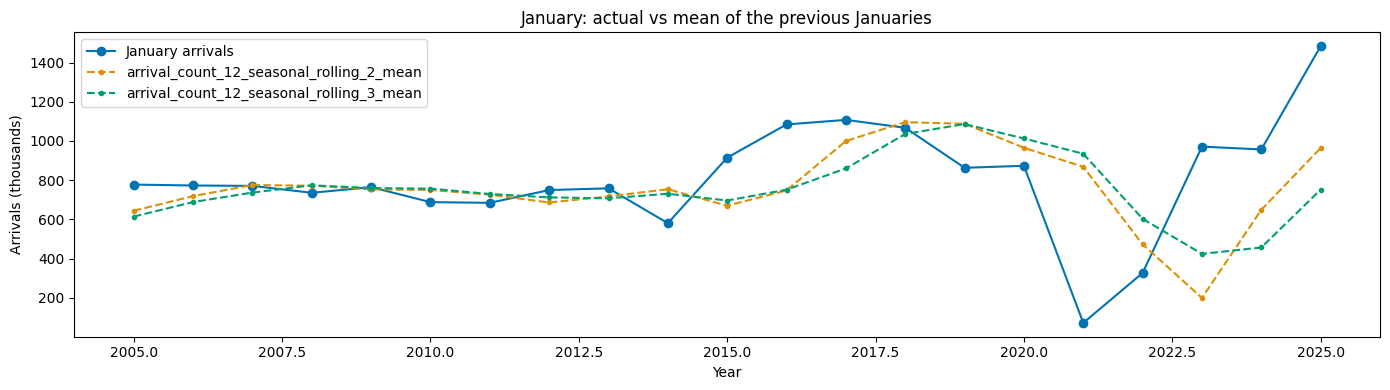

In [13]:
january = features['recursive'].query('date.dt.month == 1 and date >= "2005-01-01"')
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(
    january['date'].dt.year, january[TARGET] / 1e3, marker='o', label='January arrivals'
)
for window in SEASONAL_WINDOWS:
    col = f'{TARGET}_12_seasonal_rolling_{window}_mean'
    ax.plot(
        january['date'].dt.year,
        january[col] / 1e3,
        marker='.',
        linestyle='--',
        label=col,
    )
ax.set_title('January: actual vs mean of the previous Januaries')
ax.set_xlabel('Year')
ax.set_ylabel('Arrivals (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 7 — Exponentially Weighted Moving Average (EWMA)

**What.** An EWMA averages **all** of the history, with weights that decay exponentially:
`EWMA_t = α·y_t + (1 − α)·EWMA_{t-1}`. It gives long memory in one column while favouring
recent months.

**How.** `add_ewma(df, column, spans, ts_id, n_shift)` (book), with `n_shift = min_shift` as
in the rolling windows. A span `S` corresponds to `α = 2 / (1 + S)`:

| span | α | half-life (months) |
|---|---|---|
| 3 | 0.50 | ≈ 1.0 |
| 6 | 0.29 | ≈ 2.1 |
| 12 | 0.15 | ≈ 4.3 |

**Output.** The shorter span follows the seasonal swings. The longer spans smooth them toward
the level.

In [14]:
def add_ewma_features(df, cfg):
    # spans must be passed: the helper fails when only alphas are given
    return add_ewma(
        df,
        column=TARGET,
        alphas=None,
        spans=EWMA_SPANS,
        ts_id=TS_ID,
        n_shift=cfg['min_shift'],
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['ewma'] = add_ewma_features(
        features[name], cfg
    )

show_step('ewma')

,n_features,features
recursive,3,"arrival_count_ewma_span_3, arrival_count_ewma_..."
direct,3,"arrival_count_ewma_span_3, arrival_count_ewma_..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_ewma_span_3,arrival_count_ewma_span_6,arrival_count_ewma_span_12
date,,,,,
2024-06-30,train,332474.0,458655.934161,532149.381254,531070.870609
2024-07-31,train,437103.0,395564.967080,475099.272324,500517.505900
2024-08-31,train,417940.0,416333.983540,464243.194517,490761.428069
2024-09-30,val,445389.0,417136.991770,451013.710369,479558.131443
2024-10-31,val,508738.0,431262.995885,449406.650264,474301.341990
2024-11-30,val,560732.0,470000.497943,466358.464474,479599.289376


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_ewma_span_3,arrival_count_ewma_span_6,arrival_count_ewma_span_12
date,,,,,
2024-06-30,train,332474.0,342843.160791,413463.392736,412916.322819
2024-07-31,train,437103.0,359245.580396,402658.994811,407182.734693
2024-08-31,train,417940.0,362143.290198,391910.996294,400699.390894
2024-09-30,val,445389.0,357249.145099,380609.283067,393261.792295
2024-10-31,val,508738.0,383586.572549,388984.916476,395825.208865
2024-11-30,val,560732.0,443990.786275,421959.226055,412528.253655


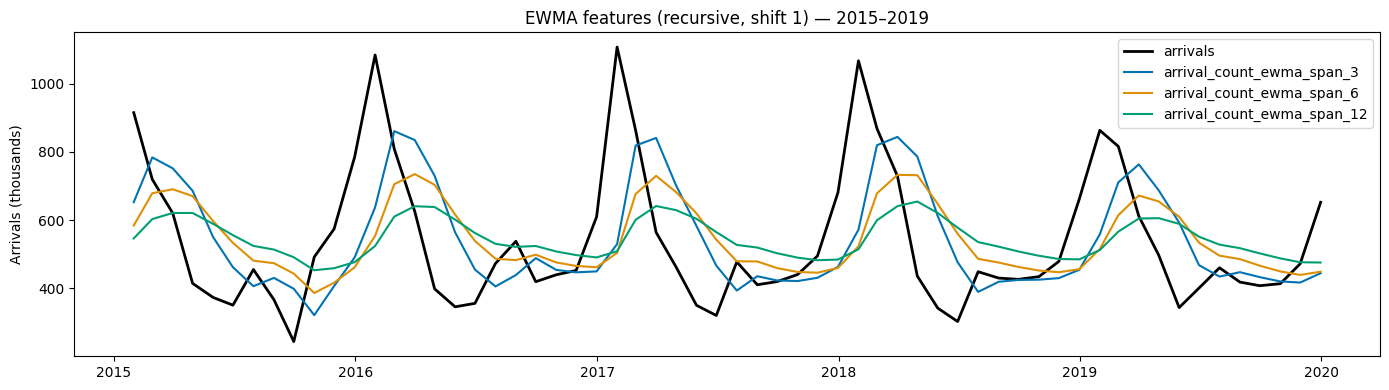

In [15]:
view = features['recursive'].query('"2015-01-01" <= date < "2020-01-01"')
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(view['date'], view[TARGET] / 1e3, color='black', linewidth=2, label='arrivals')
for span in EWMA_SPANS:
    col = f'{TARGET}_ewma_span_{span}'
    ax.plot(view['date'], view[col] / 1e3, label=col)
ax.set_title('EWMA features (recursive, shift 1) — 2015–2019')
ax.set_ylabel('Arrivals (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — Calendar Features and Elapsed Time (Temporal Embedding)

**What.** Temporal embedding builds features from the **timestamp**, not from past target
values, so they are known for any future date.

- **Month and quarter** capture the tourism calendar: the southern-hemisphere summer and
  Carnival (January–March) and the July holidays.
- **`Elapsed`** is a monotonically increasing time counter, in seconds since the epoch. It lets
  linear and neural models estimate a long-term trend. Trees **cannot extrapolate** it beyond
  the training range, which is why the target transformation of notebook 7 matters for XGBoost.

**How.** `add_temporal_features(df, field_name='date', frequency='ME', add_elapsed=True,
prefix='cal', drop=False)` (book). For a month-end frequency, the helper returns month,
quarter, the quarter/year start and end flags, and elapsed time.

- The dates are **month ends**, so `Is_quarter_start` and `Is_year_start` are always `False`.
  These constant columns carry no information and are dropped.
- Boolean flags are cast to `0/1`.
- `Elapsed` comes back as `object` dtype and is cast to `int64`.

**Output.** The box plot shows why the month matters: the level of arrivals depends strongly on
the calendar month.

In [16]:
# month-end dates never start a quarter or a year → the helper's flags are constant
CONSTANT_ON_MONTH_END = ['cal_Is_quarter_start', 'cal_Is_year_start']


def add_calendar_features(df, cfg):
    df, added = add_temporal_features(
        df,
        field_name='date',
        frequency=FREQ,
        add_elapsed=True,
        prefix='cal',
        drop=False,
    )
    assert all((df[c] == df[c].iloc[0]).all() for c in CONSTANT_ON_MONTH_END)
    df = df.drop(columns=CONSTANT_ON_MONTH_END)
    added = [c for c in added if c not in CONSTANT_ON_MONTH_END]
    flag_cols = [c for c in added if c.startswith('cal_Is_')]
    df[flag_cols] = df[flag_cols].astype(int)
    df['cal_Elapsed'] = df['cal_Elapsed'].astype('int64')
    return df, added


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['calendar'] = add_calendar_features(
        features[name].copy(), cfg
    )

show_step('calendar')

,n_features,features
recursive,5,"cal_Month, cal_Quarter, cal_Is_quarter_end, ca..."
direct,5,"cal_Month, cal_Quarter, cal_Is_quarter_end, ca..."


recursive — sample around the train/validation boundary


,split,arrival_count,cal_Month,cal_Quarter,cal_Is_quarter_end,cal_Is_year_end,cal_Elapsed
date,,,,,,,
2024-06-30,train,332474.0,6,2,1,0,1719705600
2024-07-31,train,437103.0,7,3,0,0,1722384000
2024-08-31,train,417940.0,8,3,0,0,1725062400
2024-09-30,val,445389.0,9,3,1,0,1727654400
2024-10-31,val,508738.0,10,4,0,0,1730332800
2024-11-30,val,560732.0,11,4,0,0,1732924800


direct — sample around the train/validation boundary


,split,arrival_count,cal_Month,cal_Quarter,cal_Is_quarter_end,cal_Is_year_end,cal_Elapsed
date,,,,,,,
2024-06-30,train,332474.0,6,2,1,0,1719705600
2024-07-31,train,437103.0,7,3,0,0,1722384000
2024-08-31,train,417940.0,8,3,0,0,1725062400
2024-09-30,val,445389.0,9,3,1,0,1727654400
2024-10-31,val,508738.0,10,4,0,0,1730332800
2024-11-30,val,560732.0,11,4,0,0,1732924800


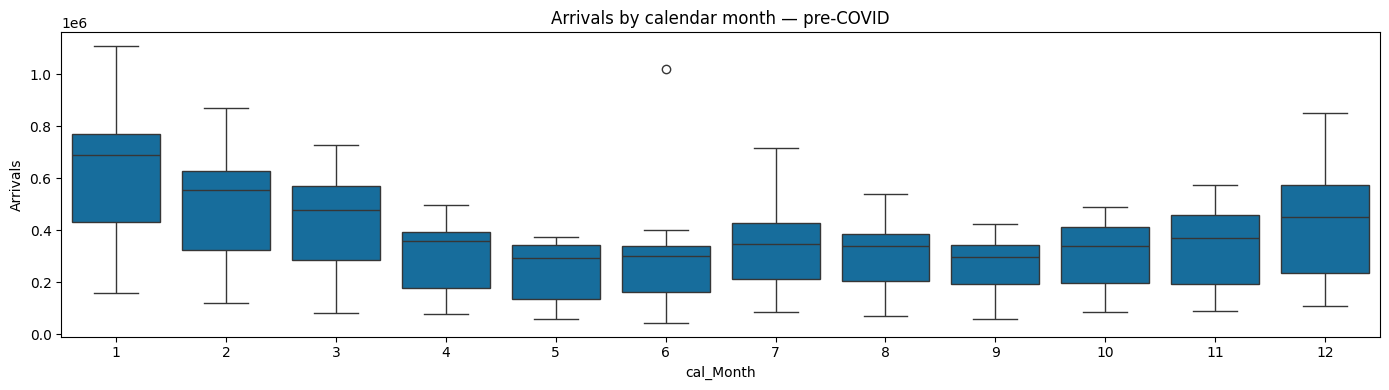

In [17]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(
    data=features['recursive'].query('date < @COVID_START'),
    x='cal_Month',
    y=TARGET,
    ax=ax,
)
ax.set_title('Arrivals by calendar month — pre-COVID')
ax.set_ylabel('Arrivals')
plt.tight_layout()
plt.show()

## Step 9 — Fourier Terms (Trigonometric Seasonality)

**What.** The month is also encoded as sine/cosine pairs:
`sin(2π·n·month / 12)` and `cos(2π·n·month / 12)` for `n = 1, …, N`.

- Unlike the integer month, December (12) and January (1) end up **close** to each other.
- The curves are smooth, so a model can build the seasonal shape from a few columns.
- More terms (`n`) capture sharper seasonal patterns. `N = 3` covers yearly, half-yearly and
  quarterly cycles.

**How.** `add_fourier_features(df, column_to_encode='cal_Month', max_value=12,
n_fourier_terms=3)` (book).

**Output.** The six curves over the 12 months. As noted in the study notes, whether the
**calendar** or the **Fourier** encoding works better is an empirical question. Both are kept,
and notebook 7 compares them (see `feature_groups`).

In [18]:
def add_fourier_month_features(df, cfg):
    # max_value must be passed: the helper raises when it has to infer it
    return add_fourier_features(
        df, column_to_encode='cal_Month', max_value=12, n_fourier_terms=FOURIER_TERMS
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['fourier'] = add_fourier_month_features(
        features[name].copy(), cfg
    )

# the last 12 training months: one full cycle of the month
show_step('fourier', rows=slice(TRAIN_END - pd.offsets.MonthEnd(11), TRAIN_END))

,n_features,features
recursive,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
direct,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."


recursive — sample around the train/validation boundary


,split,arrival_count,cal_Month_sin_1,cal_Month_sin_2,cal_Month_sin_3,cal_Month_cos_1,cal_Month_cos_2,cal_Month_cos_3
date,,,,,,,,
2023-09-30,train,352355.0,-1.000000e+00,3.673940e-16,1.000000e+00,-1.836970e-16,-1.0,5.510911e-16
2023-10-31,train,409924.0,-8.660254e-01,-8.660254e-01,2.388680e-15,5.000000e-01,-0.5,-1.000000e+00
2023-11-30,train,504395.0,-5.000000e-01,-8.660254e-01,-1.000000e+00,8.660254e-01,0.5,-2.449913e-15
2023-12-31,train,621171.0,-2.449294e-16,-4.898587e-16,-7.347881e-16,1.000000e+00,1.0,1.000000e+00
2024-01-31,train,956737.0,5.000000e-01,8.660254e-01,1.000000e+00,8.660254e-01,0.5,6.123234e-17
2024-02-29,train,833306.0,8.660254e-01,8.660254e-01,1.224647e-16,5.000000e-01,-0.5,-1.000000e+00
2024-03-31,train,740483.0,1.000000e+00,1.224647e-16,-1.000000e+00,6.123234e-17,-1.0,-1.836970e-16
2024-04-30,train,398587.0,8.660254e-01,-8.660254e-01,-2.449294e-16,-5.000000e-01,-0.5,1.000000e+00
2024-05-31,train,335652.0,5.000000e-01,-8.660254e-01,1.000000e+00,-8.660254e-01,0.5,1.194340e-15


direct — sample around the train/validation boundary


,split,arrival_count,cal_Month_sin_1,cal_Month_sin_2,cal_Month_sin_3,cal_Month_cos_1,cal_Month_cos_2,cal_Month_cos_3
date,,,,,,,,
2023-09-30,train,352355.0,-1.000000e+00,3.673940e-16,1.000000e+00,-1.836970e-16,-1.0,5.510911e-16
2023-10-31,train,409924.0,-8.660254e-01,-8.660254e-01,2.388680e-15,5.000000e-01,-0.5,-1.000000e+00
2023-11-30,train,504395.0,-5.000000e-01,-8.660254e-01,-1.000000e+00,8.660254e-01,0.5,-2.449913e-15
2023-12-31,train,621171.0,-2.449294e-16,-4.898587e-16,-7.347881e-16,1.000000e+00,1.0,1.000000e+00
2024-01-31,train,956737.0,5.000000e-01,8.660254e-01,1.000000e+00,8.660254e-01,0.5,6.123234e-17
2024-02-29,train,833306.0,8.660254e-01,8.660254e-01,1.224647e-16,5.000000e-01,-0.5,-1.000000e+00
2024-03-31,train,740483.0,1.000000e+00,1.224647e-16,-1.000000e+00,6.123234e-17,-1.0,-1.836970e-16
2024-04-30,train,398587.0,8.660254e-01,-8.660254e-01,-2.449294e-16,-5.000000e-01,-0.5,1.000000e+00
2024-05-31,train,335652.0,5.000000e-01,-8.660254e-01,1.000000e+00,-8.660254e-01,0.5,1.194340e-15


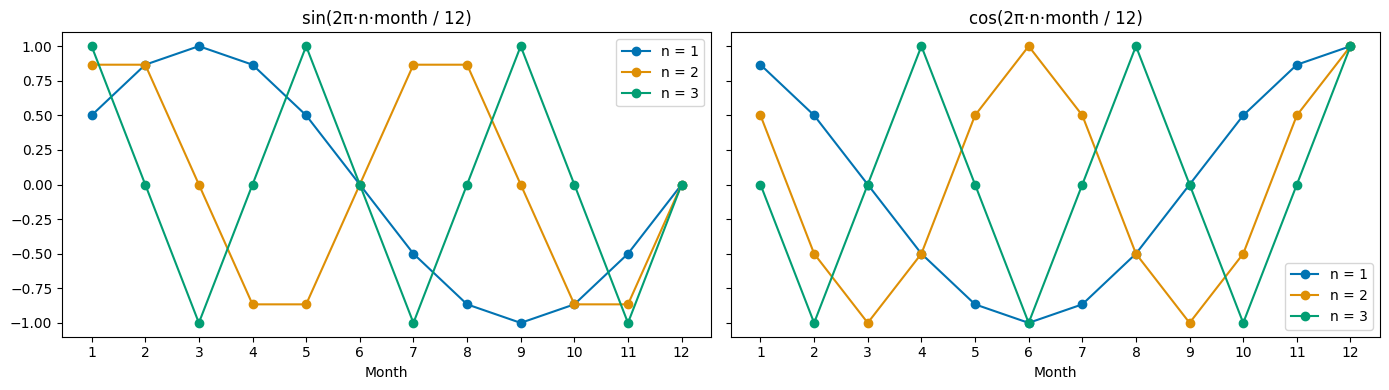

In [19]:
one_year = (
    features['recursive']
    .set_index('date')
    .loc[TRAIN_END - pd.offsets.MonthEnd(11) : TRAIN_END]
    .set_index('cal_Month')
    .sort_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, kind in zip(axes, ['sin', 'cos']):
    for n in range(1, FOURIER_TERMS + 1):
        ax.plot(
            one_year.index,
            one_year[f'cal_Month_{kind}_{n}'],
            marker='o',
            label=f'n = {n}',
        )
    ax.set_title(f'{kind}(2π·n·month / 12)')
    ax.set_xticks(range(1, 13))
    ax.set_xlabel('Month')
    ax.legend()
plt.tight_layout()
plt.show()

## Step 10 — Domain Features (Project-Specific)

These features are **not** in the book. They come from the analysis in notebooks 3–5 and
from the calendar. All are known in advance for any future month.

| Feature | Definition | Why |
|---|---|---|
| `is_covid` | 1 for Jan 2020 – Dec 2021 | The structural break. The same regressor as the SARIMAX baseline |
| `is_covid_recovery` | 1 for Jan – Jun 2022 | The rebound period (notebook 5) |
| `is_covid_lag_k` | `is_covid` at each lag of the strategy (book `add_lags`) | Warns the model that `lag_k` holds a pandemic value. For example, 2022 rows have a collapsed `lag_12` |
| `days_in_month` | 28–31 | Monthly totals scale with the number of days |

**Output.** The COVID contamination of `lag_12` in 2021–2022.

In [20]:
def add_domain_features(df, cfg):
    df = df.copy()
    df['is_covid'] = df['date'].between(COVID_START, COVID_END).astype(int)
    df['is_covid_recovery'] = (
        df['date'].between(POST_COVID_START, COVID_RECOVERY_END).astype(int)
    )
    df['days_in_month'] = df['date'].dt.days_in_month
    added = ['is_covid', 'is_covid_recovery', 'days_in_month']

    # flag the lag positions that point into the pandemic (no COVID before 1989)
    df, covid_lags = add_lags(df, lags=cfg['lags'], column='is_covid', ts_id=TS_ID)
    df[covid_lags] = df[covid_lags].fillna(0).astype(int)
    return df, added + covid_lags


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['domain'] = add_domain_features(
        features[name], cfg
    )

show_step('domain', rows=slice('2021-11-30', '2022-03-31'))

,n_features,features
recursive,9,"is_covid, is_covid_recovery, days_in_month, is..."
direct,7,"is_covid, is_covid_recovery, days_in_month, is..."


recursive — sample around the train/validation boundary


,split,arrival_count,is_covid,is_covid_recovery,days_in_month,is_covid_lag_1,is_covid_lag_2,is_covid_lag_12,is_covid_lag_13,is_covid_lag_24,is_covid_lag_36
date,,,,,,,,,,,
2021-11-30,train,107123.0,1,0,30,1,1,1,1,0,0
2021-12-31,train,174834.0,1,0,31,1,1,1,1,0,0
2022-01-31,train,326670.0,0,1,31,1,1,1,1,1,0
2022-02-28,train,311342.0,0,1,28,0,1,1,1,1,0
2022-03-31,train,276708.0,0,1,31,0,0,1,1,1,0


direct — sample around the train/validation boundary


,split,arrival_count,is_covid,is_covid_recovery,days_in_month,is_covid_lag_12,is_covid_lag_13,is_covid_lag_24,is_covid_lag_36
date,,,,,,,,,
2021-11-30,train,107123.0,1,0,30,1,1,0,0
2021-12-31,train,174834.0,1,0,31,1,1,0,0
2022-01-31,train,326670.0,0,1,31,1,1,1,0
2022-02-28,train,311342.0,0,1,28,1,1,1,0
2022-03-31,train,276708.0,0,1,31,1,1,1,0


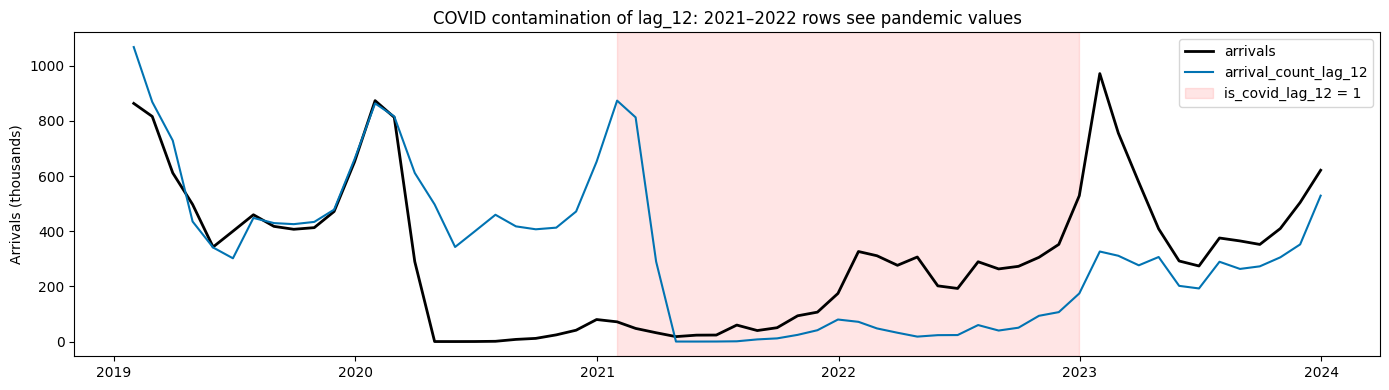

In [21]:
frame = features['recursive']
fig, ax = plt.subplots(figsize=(14, 4))
view = frame.query('"2019-01-01" <= date < "2024-01-01"')
ax.plot(view['date'], view[TARGET] / 1e3, color='black', linewidth=2, label='arrivals')
ax.plot(view['date'], view[f'{TARGET}_lag_12'] / 1e3, label=f'{TARGET}_lag_12')
contaminated = view.loc[view['is_covid_lag_12'] == 1, 'date']
ax.axvspan(
    contaminated.min(),
    contaminated.max(),
    color='red',
    alpha=0.1,
    label='is_covid_lag_12 = 1',
)
ax.set_title('COVID contamination of lag_12: 2021–2022 rows see pandemic values')
ax.set_ylabel('Arrivals (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

**Reading.** From January 2021 to December 2022, `lag_12` holds pandemic values
that say nothing about the actual level. The same happens to the rolling, seasonal and EWMA
features that reach into 2020–2021. `is_covid_lag_k` marks these rows for the model. The
further the forecast window moves from the pandemic, the fewer lags reach into it: the table
in Step 10 shows which `is_covid_lag_k` flags are still active on the validation rows.

## Step 11 — The Feature Pipeline

**What.** Steps 4–10 are wrapped into one function, `build_feature_matrix(monthly, strategy)`.
It applies the same step functions in order and returns the feature table and its feature
groups.

- Notebook 7 needs this function to rebuild the recursive features as predictions are fed back.
- Step 12 needs it to rerun the whole pipeline on perturbed data for the leakage check.

**Output.** The pipeline must reproduce the step-by-step tables exactly.

In [22]:
FEATURE_STEPS = [
    ('lags', add_lag_features),
    ('rolling', add_rolling_window_features),
    ('seasonal_rolling', add_seasonal_window_features),
    ('ewma', add_ewma_features),
    ('calendar', add_calendar_features),
    ('fourier', add_fourier_month_features),
    ('domain', add_domain_features),
]
TARGET_DERIVED_GROUPS = ['lags', 'rolling', 'seasonal_rolling', 'ewma']


def build_feature_matrix(monthly_df, strategy):
    """Apply every feature step to a copy of the monthly series for one strategy."""
    cfg = STRATEGIES[strategy]
    df = monthly_df.copy()
    groups = {}
    for group, step in FEATURE_STEPS:
        df, groups[group] = step(df, cfg)
    return df, groups


for name in STRATEGIES:
    rebuilt, groups = build_feature_matrix(monthly, name)
    pd.testing.assert_frame_equal(rebuilt, features[name])
    assert groups == feature_groups[name]
    print(
        f'{name:<9}: pipeline reproduces the step-by-step table '
        f'({rebuilt.shape[1]} columns)'
    )

display(
    pd.DataFrame({
        name: {group: len(cols) for group, cols in groups.items()}
        for name, groups in feature_groups.items()
    }).assign(**{'target-derived': lambda d: d.index.isin(TARGET_DERIVED_GROUPS)})
)

recursive: pipeline reproduces the step-by-step table (49 columns)
direct   : pipeline reproduces the step-by-step table (45 columns)


,recursive,direct,target-derived
lags,6,4,True
rolling,12,12,True
seasonal_rolling,4,4,True
ewma,3,3,True
calendar,5,5,False
fourier,6,6,False
domain,9,7,False


## Step 12 — Leakage Check

**What.** A feature leaks if the value at row `t` depends on data that would not be available
when forecasting `t`. The test checks this directly instead of trusting each `shift`:

1. Pick a cutoff date and **multiply every value after it by 10**.
2. Rebuild the features with the pipeline.
3. Rows up to `cutoff + min_shift` must keep **identical** target-derived features, since
   they may only see data up to the cutoff.
4. Negative control: the next row must **change**, which proves the test can detect a
   difference. It does not apply when that row lies beyond the data (`None`).

For the direct strategy, cutoff = `TRAIN_END` covers the whole validation window. None of
the validation features may depend on validation values.

In [23]:
def target_derived_columns(groups):
    return [col for group in TARGET_DERIVED_GROUPS for col in groups[group]]


def check_no_leakage(strategy, cutoff):
    min_shift = STRATEGIES[strategy]['min_shift']
    base, groups = build_feature_matrix(monthly, strategy)
    perturbed = monthly.copy()
    perturbed.loc[perturbed['date'] > cutoff, TARGET] *= 10
    shocked, _ = build_feature_matrix(perturbed, strategy)

    cols = target_derived_columns(groups)
    last_safe = cutoff + pd.offsets.MonthEnd(min_shift)
    safe = base['date'] <= last_safe
    first_unsafe = base['date'] == last_safe + pd.offsets.MonthEnd(1)
    unchanged = np.allclose(
        base.loc[safe, cols], shocked.loc[safe, cols], equal_nan=True
    )
    # control is not applicable when the next row is beyond the data
    detects = (
        not np.allclose(
            base.loc[first_unsafe, cols],
            shocked.loc[first_unsafe, cols],
            equal_nan=True,
        )
        if first_unsafe.any()
        else None
    )
    return {
        'strategy': strategy,
        'cutoff': f'{cutoff:%b %Y}',
        'rows that must not change': f'up to {last_safe:%b %Y}',
        'unchanged (no leakage)': unchanged,
        'next row changes (control)': detects,
    }


leakage = pd.DataFrame([
    check_no_leakage(strategy, cutoff)
    for strategy in STRATEGIES
    for cutoff in [pd.Timestamp('2015-06-30'), TRAIN_END]
])
display(leakage)
assert leakage['unchanged (no leakage)'].all()
assert leakage['next row changes (control)'].dropna().all()

,strategy,cutoff,rows that must not change,unchanged (no leakage),next row changes (control)
0,recursive,Jun 2015,up to Jul 2015,True,True
1,recursive,Aug 2024,up to Sep 2024,True,True
2,direct,Jun 2015,up to Jun 2016,True,True
3,direct,Aug 2024,up to Aug 2025,True,None


## Step 13 — Warm-up Rows and Test-Row Masking

**What.** Two cleaning rules turn the working tables into model-ready data.

1. **Warm-up.** The first rows cannot have all of their features: `lag_36` needs 36 months of
   history, and the 3-year seasonal window also reaches back 36 months. These rows are dropped.
   The loss is small, since the series starts in 1989.
2. **Recursive validation rows.** In the recursive table, the target-derived features of the
   validation rows were computed from the **actual** validation values (Step 4). They are set to `NaN`, so the
   saved file cannot be used for an accidental one-step-ahead evaluation. Notebook 7 fills them
   month by month from the model's predictions, using `build_feature_matrix`.

   The direct table needs no masking: Step 12 proved its validation features only use training
   data.

In [24]:
model_ready = {}
for name, frame in features.items():
    cols = target_derived_columns(feature_groups[name])
    complete = frame[cols].notna().all(axis=1)
    first_complete = frame.loc[complete, 'date'].min()
    ready = frame[frame['date'] >= first_complete].reset_index(drop=True)
    train_nans = int(ready.loc[ready['split'] == 'train', cols].isna().sum().sum())
    if name == 'recursive':
        ready.loc[ready['split'] == 'val', cols] = np.nan
    model_ready[name] = ready
    print(
        f'{name:<9}: first complete row {first_complete:%b %Y} | '
        f'dropped {len(frame) - len(ready)} warm-up rows | '
        f'{ready.query("split == 'train'").shape[0]} train + '
        f'{ready.query("split == 'val'").shape[0]} validation rows | '
        f'NaNs left in train: {train_nans}'
    )

recursive: first complete row Jan 1992 | dropped 36 warm-up rows | 392 train + 12 validation rows | NaNs left in train: 0
direct   : first complete row Jan 1992 | dropped 36 warm-up rows | 392 train + 12 validation rows | NaNs left in train: 0


## Step 14 — Feature Overview

**What.** A first look at how each feature relates to the target. This is **not** feature
selection (planned for notebook 7), only a sanity check that the features carry signal.

**How.** The Spearman (rank) correlation with the target on the **pre-COVID training rows**,
since the pandemic would dominate any correlation. `split`, the id and the target are
excluded. The top features of each strategy are shown.

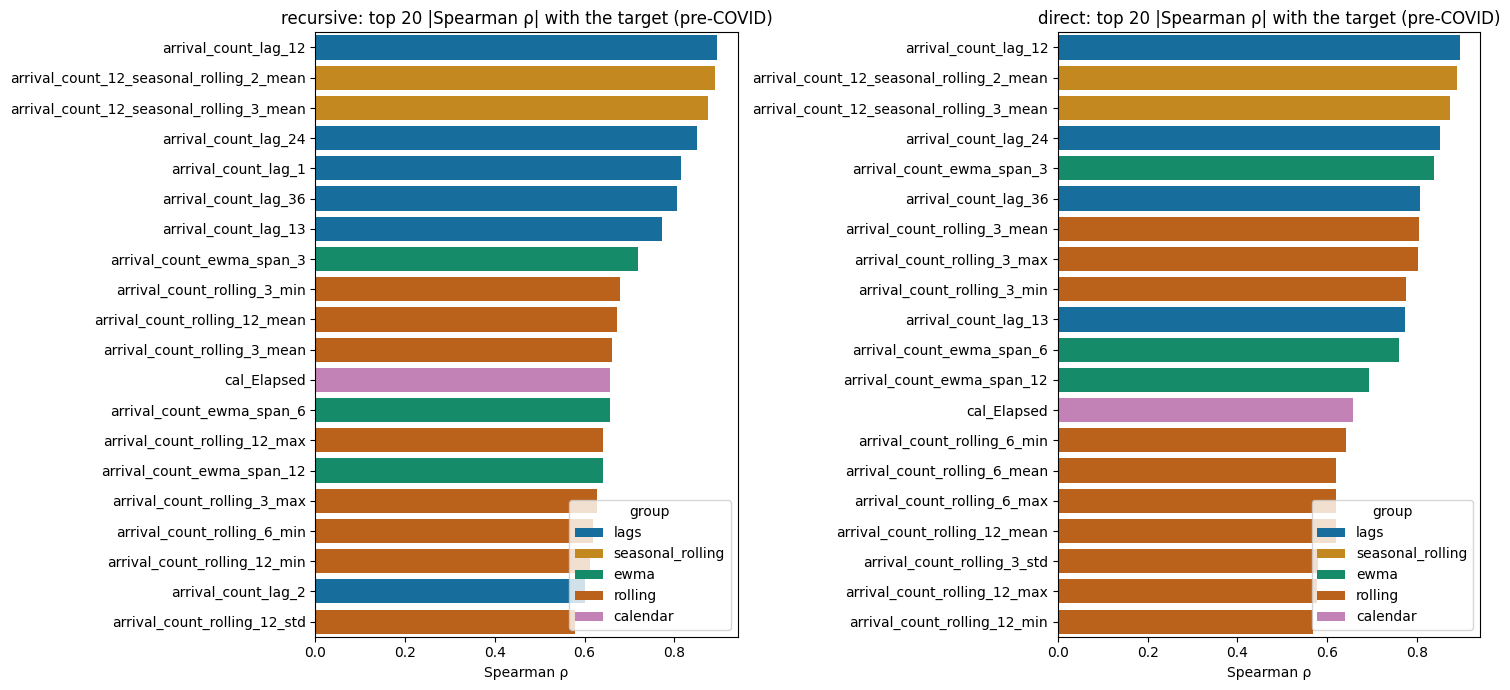

In [25]:
def feature_columns(groups):
    return [col for cols in groups.values() for col in cols]


TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (name, frame) in zip(axes, model_ready.items()):
    pre = frame.query('split == "train" and date < @COVID_START')
    cols = [
        c
        for c in feature_columns(feature_groups[name])
        if not (pre[c] == pre[c].iloc[0]).all()
    ]
    corr = pre[cols].corrwith(pre[TARGET], method='spearman')
    top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(TOP_N)
    group_of = {c: g for g, cs in feature_groups[name].items() for c in cs}
    sns.barplot(
        x=top.values, y=top.index, hue=top.index.map(group_of), dodge=False, ax=ax
    )
    ax.set_title(f'{name}: top {TOP_N} |Spearman ρ| with the target (pre-COVID)')
    ax.set_xlabel('Spearman ρ')
    ax.set_ylabel('')
    ax.legend(title='group', loc='lower right')
plt.tight_layout()
plt.show()

## Step 15 — Save the Feature Tables

**Outputs** (in `data/processed/`), consumed by notebook 7:

| File | Content |
|---|---|
| `features_recursive.parquet` | Recursive table: train rows complete, validation target-derived features masked (`NaN`) |
| `features_direct.parquet` | Direct table: complete for train and validation |
| `feature_groups.json` | Target and id columns, the feature columns of each strategy by group, and the parameters used |

Every table keeps `date`, `series_id`, `split` and the **raw** target `arrival_count`. The
target transformation (`none` / `log` / `AutoStationaryTransformer`) is applied in notebook 7
and inverse-transformed before scoring, as in notebook 5.

In [26]:
feature_spec = {
    'target': TARGET,
    'id_columns': ['date', TS_ID, 'split'],
    'horizon': HORIZON,
    'target_derived_groups': TARGET_DERIVED_GROUPS,
    'strategies': {
        name: {
            **STRATEGIES[name],
            'file': f'features_{name}.parquet',
            'groups': feature_groups[name],
        }
        for name in STRATEGIES
    },
    'parameters': {
        'rolling_windows': ROLLING_WINDOWS,
        'rolling_aggs': ROLLING_AGGS,
        'seasonal_period': SEASONAL_PERIOD,
        'seasonal_windows': SEASONAL_WINDOWS,
        'seasonal_aggs': SEASONAL_AGGS,
        'ewma_spans': EWMA_SPANS,
        'fourier_terms': FOURIER_TERMS,
    },
}

for name, frame in model_ready.items():
    path = os.path.join(DATA_FOLDER_PATH, f'features_{name}.parquet')
    frame.to_parquet(path, index=False)
    print(f'{path} → {frame.shape}')

spec_path = os.path.join(DATA_FOLDER_PATH, 'feature_groups.json')
with open(spec_path, 'w', encoding='utf-8') as f:
    json.dump(feature_spec, f, indent=2)
print(f'{spec_path} written')

c:\git_reps\brazil_tourism_forecasting_benchmark\data\processed\features_recursive.parquet → (404, 49)
c:\git_reps\brazil_tourism_forecasting_benchmark\data\processed\features_direct.parquet → (404, 45)
c:\git_reps\brazil_tourism_forecasting_benchmark\data\processed\feature_groups.json written


## Key Takeaways

**What was built.** A reusable pipeline (`build_feature_matrix`) that turns the monthly series
into two model-ready tables, from the first complete month (after 36 warm-up months) to the
last validation month (the test set is not included). Step 13 prints the exact date range and row counts:

| Strategy | Features | Target-derived | Temporal + domain |
|---|---|---|---|
| recursive | 45 | 25 (lags 1, 2, 12, 13, 24, 36; rolling; seasonal; EWMA, shift ≥ 1) | 20 |
| direct | 41 | 23 (lags 12, 13, 24, 36; rolling; seasonal; EWMA, shift ≥ 12) | 18 |